In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader
import random
from sklearn.model_selection import train_test_split

# Load dataset
file_path = r"/content/drive/My Drive/bug/DATASET.csv"
df = pd.read_csv(file_path)

In [ ]:
import numpy as np
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
# Convert bug descriptions into embeddings
descriptions = df["Short Description"].astype(str).tolist()
embeddings = sbert_model.encode(descriptions, convert_to_numpy=True)

# Convert category names to numerical labels
df["Label"] = df["Category"].astype("category").cat.codes
labels = df["Label"].values

# Save embeddings and labels for future use
np.save("bug_embeddings1.npy", embeddings)
np.save("bug_labels1.npy", labels)
print("✔️ Embeddings generated and saved!")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
import numpy as np

# Save to Drive
np.save('/content/drive/My Drive/bug/bug_embeddings1.npy', embeddings)
np.save('/content/drive/My Drive/bug/bug_labels1.npy', labels)

print("✔️ NumPy array saved!")


✔️ NumPy array saved!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

In [ ]:
num_samples = 1000
embedding_dim = 384

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ==============================
# 🔹 Siamese Network
# ==============================
class SiameseNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super(SiameseNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.normalize(x, p=2, dim=1)  # L2 normalization
        return x  # Embedding output

# ==============================
# 🔹 Contrastive Loss Function
# ==============================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = torch.norm(anchor - positive, p=2, dim=1) ** 2
        neg_dist = torch.norm(anchor - negative, p=2, dim=1) ** 2
        loss = torch.mean(F.relu(pos_dist - neg_dist + self.margin))  # Hinge loss
        return loss

# ==============================
# 🔹 Custom Dataset for Training
# ==============================
class BugDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.scaler = StandardScaler()
        self.embeddings = self.scaler.fit_transform(embeddings)  # Normalize features
        self.labels = labels

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, index):
        anchor = self.embeddings[index]
        anchor_label = self.labels[index]

        positive_indices = np.where(self.labels == anchor_label)[0]
        positive = self.embeddings[np.random.choice(positive_indices)]

        negative_indices = np.where(self.labels != anchor_label)[0]
        negative = self.embeddings[np.random.choice(negative_indices)]

        return (
            torch.tensor(anchor, dtype=torch.float32),
            torch.tensor(positive, dtype=torch.float32),
            torch.tensor(negative, dtype=torch.float32)
        )

# ==============================
# 🔹 Load Dataset
# ==============================

dataset = BugDataset(embeddings, labels)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# ==============================
# 🔹 Train Siamese Network
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork(input_dim=384, embedding_dim=128).to(device)
criterion = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 10  # Train for a fixed number of epochs

for epoch in range(num_epochs):
    total_loss = 0.0
    for anchor, positive, negative in dataloader:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        optimizer.zero_grad()
        anchor_embed = model(anchor)
        positive_embed = model(positive)
        negative_embed = model(negative)

        loss = criterion(anchor_embed, positive_embed, negative_embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    scheduler.step(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("✔️ Siamese Network training complete!")


NameError: name 'embeddings' is not defined

In [ ]:
save_path = "/content/drive/MyDrive/bug/siamese_model2.pth"  # Adjust path as needed
torch.save(model.state_dict(), save_path)
print(f"✔ Model saved at {save_path}")

NameError: name 'model' is not defined

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Define the same model structure
class SiameseNetwork(nn.Module):
    def __init__(self, input_dim=384, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = torch.nn.functional.normalize(x, p=2, dim=1)  # L2 normalization
        return x  # Embedding output

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/content/drive/MyDrive/bug/siamese_model2.pth"  # Adjust if needed
siamese_model = SiameseNetwork().to(device)
siamese_model.load_state_dict(torch.load(model_path, map_location=device))
siamese_model.eval()  # Set model to evaluation mode
print("✅ Siamese Model Loaded Successfully!")


✅ Siamese Model Loaded Successfully!


In [ ]:
# Load precomputed embeddings
bug_embeddings = np.load("/content/drive/My Drive/bug/bug_embeddings1.npy")
bug_labels = np.load("/content/drive/My Drive/bug/bug_labels1.npy")

# Normalize embeddings
scaler = StandardScaler()
bug_embeddings = scaler.fit_transform(bug_embeddings)

# Convert to tensor
bug_embeddings = torch.tensor(bug_embeddings, dtype=torch.float32).to(device)
bug_labels = torch.tensor(bug_labels, dtype=torch.long).to(device)

# Get final embeddings from the Siamese model
with torch.no_grad():
    siamese_embeddings = siamese_model(bug_embeddings)

# Convert embeddings to NumPy for MLP training
X = siamese_embeddings.cpu().numpy()
y = bug_labels.cpu().numpy()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

# Example data (replace with your dataset)
# X, y = ...

# Data Preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (for classification tasks)
num_classes = len(np.unique(y_train))
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Build MLP Model
model = models.Sequential()
model.add(layers.InputLayer(input_shape=(X_train.shape[1],)))
model.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu', kernel_initializer='he_normal'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# Train the model
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping, lr_scheduler])

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"MLP Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.4891 - loss: 1.4240 - val_accuracy: 0.6590 - val_loss: 0.8689 - learning_rate: 0.0010
Epoch 2/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6417 - loss: 0.9311 - val_accuracy: 0.6851 - val_loss: 0.8100 - learning_rate: 0.0010
Epoch 3/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6613 - loss: 0.8806 - val_accuracy: 0.6960 - val_loss: 0.7814 - learning_rate: 0.0010
Epoch 4/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6706 - loss: 0.8523 - val_accuracy: 0.7003 - val_loss: 0.7684 - learning_rate: 0.0010
Epoch 5/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6803 - loss: 0.8336 - val_accuracy: 0.7108 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 6/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6846 - loss: 0.8190 - val_accuracy: 0.7137 - val_loss: 0.7383 - learning_rate: 0.0010
Epoch 7/100
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0

In [ ]:
# ✅ Step 10: Save the Fixed Model
import joblib
joblib.dump(model, "/content/drive/MyDrive/bug/mlp_3.pkl")

['/content/drive/MyDrive/bug/mlp_3.pkl']

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 🔹 Train-test split (Use stratified split for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Feature Scaling (Standardizing embeddings)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 One-hot encode labels
y_train = keras.utils.to_categorical(y_train, num_classes=5)
y_test = keras.utils.to_categorical(y_test, num_classes=5)

# 🔹 Define Input Layer
input_layer = layers.Input(shape=(X_train.shape[1],))

# 🔹 Optimized MLP Architecture
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)  # 🔹 Increased dropout

x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)  # 🔹 Increased dropout

# 🔹 Output Layer (Softmax for 5-class classification)
output_layer = layers.Dense(5, activation='softmax')(x)

# 🏗️ Build Model
model = keras.Model(inputs=input_layer, outputs=output_layer)

# 🔹 Compile Model (Lower LR for better generalization)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),  # 🔹 Slightly lower LR
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Early Stopping (Stronger regularization)
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# 🔹 Evaluate Model
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)

print(f"✅ Final MLP Accuracy: {accuracy:.4f}")

Epoch 1/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4511 - loss: 1.8799 - val_accuracy: 0.6749 - val_loss: 1.1639
Epoch 2/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.6357 - loss: 1.2636 - val_accuracy: 0.7033 - val_loss: 1.0506
Epoch 3/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6720 - loss: 1.1188 - val_accuracy: 0.7152 - val_loss: 0.9761
Epoch 4/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6903 - loss: 1.0361 - val_accuracy: 0.7262 - val_loss: 0.9116
Epoch 5/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7030 - loss: 0.9621 - val_accuracy: 0.7351 - val_loss: 0.8590
Epoch 6/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7110 - loss: 0.9135 - val_accuracy: 0.7448 - val_loss: 0.8210
Epoch 7/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7239 - loss: 0.8644 - val_accuracy: 0.7525 - val_loss: 0.7828
Epoch 8/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7250 - loss: 0.838

In [ ]:
print("X_train shape:", X_train.shape)  # Debugging step

X_train shape: (70945, 128)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 🔹 Train-test split (Use stratified split for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Feature Scaling (Standardizing embeddings)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 One-hot encode labels
y_train = keras.utils.to_categorical(y_train, num_classes=5)
y_test = keras.utils.to_categorical(y_test, num_classes=5)

# 🔹 Define Optimized MLP Model
def build_model(input_shape):
    input_layer = layers.Input(shape=(input_shape,))  # Ensure correct shape

    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)  # Increased dropout for regularization

    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    output_layer = layers.Dense(5, activation='softmax')(x)  # 5 classes

    model = keras.Model(inputs=input_layer, outputs=output_layer)
    return model

# Build Model (Pass the Correct Input Shape)
model = build_model(X_train.shape[1])

# 🔹 Compile Model (Use AdamW + Lookahead)
optimizer = keras.optimizers.AdamW(learning_rate=0.0005, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# 🔹 Callbacks for Better Convergence
#early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test), callbacks=[reduce_lr])

# 🔹 Evaluate Model
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)

print(f"✅ Final MLP Accuracy: {accuracy:.4f}")


Epoch 1/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - accuracy: 0.4365 - loss: 2.3336 - val_accuracy: 0.6687 - val_loss: 1.5263 - learning_rate: 5.0000e-04
Epoch 2/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6372 - loss: 1.5903 - val_accuracy: 0.6923 - val_loss: 1.3442 - learning_rate: 5.0000e-04
Epoch 3/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6725 - loss: 1.3780 - val_accuracy: 0.7087 - val_loss: 1.1928 - learning_rate: 5.0000e-04
Epoch 4/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6920 - loss: 1.2182 - val_accuracy: 0.7199 - val_loss: 1.0639 - learning_rate: 5.0000e-04
Epoch 5/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7022 - loss: 1.0939 - val_accuracy: 0.7264 - val_loss: 0.9662 - learning_rate: 5.0000e-04
Epoch 6/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7146 - loss: 1.0041 - val_accuracy: 0.7376 - val_loss: 0.8944 - learning_rate: 5.0000e-04
Epoch 7/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/s

In [ ]:
# ✅ Step 10: Save the Fixed Model
import joblib
joblib.dump(model, "/content/drive/MyDrive/bug/mlp_4.pkl")

['/content/drive/MyDrive/bug/mlp_4.pkl']

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 One-hot encode labels
num_classes = 5
y_train = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes=num_classes)

# 🔥 Fourier Feature Encoding Layer (Fixed Output Shape)
class FourierFeatures(layers.Layer):
    def __init__(self, num_features=128, input_dim=128):
        super(FourierFeatures, self).__init__()
        self.num_features = num_features
        self.input_dim = input_dim
        self.B = self.add_weight(name="B",
                                 shape=(self.input_dim, self.num_features),
                                 initializer="random_normal",
                                 trainable=False)

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)  # (batch, num_features)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)  # (batch, 2*num_features)

# 🔥 Attention Layer
class Attention(layers.Layer):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.dense = layers.Dense(units, activation="softmax")

    def call(self, inputs):
        attn_weights = self.dense(inputs)  # (batch, units)
        return inputs * attn_weights  # Element-wise multiplication

# 🔥 Unique MLP Model
def build_unique_mlp(input_shape, num_classes):
    inputs = layers.Input(shape=(input_shape,))

    # 🔹 Fourier Feature Encoding (Fixed)
    x = FourierFeatures(num_features=128, input_dim=input_shape)(inputs)

    # 🔹 Fully Connected Layers
    x = layers.Dense(512, activation="swish")(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # 🔹 Attention Mechanism
    x = Attention(512)(x)

    # 🔹 Final Dense Layers
    x = layers.Dense(128, activation="swish")(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

# 🔹 Build and Compile Model
model = build_unique_mlp(X_train.shape[1], num_classes)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Early Stopping and Learning Rate Scheduler
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=100, batch_size=128,
                    validation_data=(X_test, y_test), callbacks=[early_stopping, reduce_lr])

# 🔹 Evaluate Model
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)

print(f"✅ Final Unique MLP Accuracy: {accuracy:.4f}")


Epoch 1/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.5967 - loss: 1.0366 - val_accuracy: 0.6565 - val_loss: 0.8669 - learning_rate: 0.0010
Epoch 2/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6707 - loss: 0.8602 - val_accuracy: 0.6936 - val_loss: 0.7947 - learning_rate: 0.0010
Epoch 3/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.6927 - loss: 0.8008 - val_accuracy: 0.6919 - val_loss: 0.8022 - learning_rate: 0.0010
Epoch 4/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7089 - loss: 0.7665 - val_accuracy: 0.7227 - val_loss: 0.7249 - learning_rate: 0.0010
Epoch 5/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7210 - loss: 0.7316 - val_accuracy: 0.7352 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 6/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7356 - loss: 0.7044 - val_accuracy: 0.7271 - val_loss: 0.7222 - learning_rate: 0.0010
Epoch 7/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.74

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

# Example data (replace with your dataset)
# X, y = ...

# Data Preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (for classification tasks)
num_classes = len(np.unique(y_train))
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=300, random_state=42)

# Train the classifier on Siamese embeddings
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")


Random Forest Accuracy: 0.5295


In [ ]:
import joblib
joblib.dump(model, "/content/drive/MyDrive/bug/rf_classifier.pkl")

['/content/drive/MyDrive/bug/rf_classifier.pkl']

In [ ]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred = xgb_classifier.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")

XGBoost Accuracy: 0.5959


In [ ]:
import joblib
joblib.dump(model, "/content/drive/MyDrive/bug/xgb_classifier.pkl")

['/content/drive/MyDrive/bug/xgb_classifier.pkl']

In [ ]:
X = siamese_embeddings.cpu().numpy()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
gb_classifier.fit(X_train, y_train)
y_pred = gb_classifier.predict(X_test)

print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred):.4f}")


KeyboardInterrupt: 

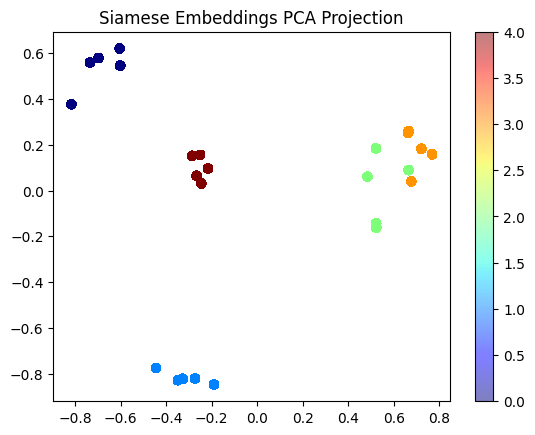

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="jet", alpha=0.5)
plt.colorbar()
plt.title("Siamese Embeddings PCA Projection")
plt.show()

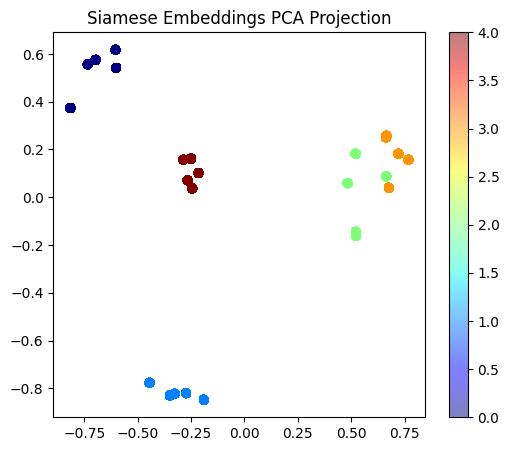

ValueError: No.

<Figure size 600x500 with 0 Axes>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

# 1️⃣ Load Your Data (Assumed Precomputed Siamese Embeddings)
# X = Your embeddings (Shape: [88000, embedding_dim])
# y = Corresponding labels

# 2️⃣ Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Visualize PCA Projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="jet", alpha=0.5)
plt.colorbar()
plt.title("Siamese Embeddings PCA Projection")
plt.show()

# 4️⃣ Visualize t-SNE Projection
X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(X_train)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_train, palette="jet", alpha=0.5)
plt.title("t-SNE of Siamese Embeddings")
plt.show()

# 5️⃣ Train MLP Classifier (Prevent Overfitting)
X_train_noisy = X_train + np.random.normal(0, 0.01, X_train.shape)  # Add noise

mlp1 = MLPClassifier(hidden_layer_sizes=(128, 128, 64), activation='relu', solver='adam',
                    max_iter=50, alpha=0.1, random_state=42)

mlp1.fit(X_train_noisy, y_train)

# 6️⃣ Evaluate Model
y_pred = mlp1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ MLP Accuracy (Generalized): {accuracy:.4f}")

In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X, y)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.7016


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Split Data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Add noise to prevent overfitting
X_train_noisy = X_train + np.random.normal(0, 0.01, X_train.shape)

# Define MLP Classifier with fixes
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
                    max_iter=30, alpha=0.05, random_state=42)

# Train Model
mlp.fit(X_train_noisy, y_train)

# Evaluate
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ MLP Accuracy (Generalized): {accuracy:.4f}")


✅ MLP Accuracy (Generalized): 1.0000


In [ ]:
import joblib

# Save the trained MLP model
joblib.dump(mlp1, "/content/drive/MyDrive/bug/mlp_model2.pkl")  # Adjust path as needed
print("✔️ MLP 2 model saved successfully!")

✔️ MLP 2 model saved successfully!


In [ ]:
category_mapping = dict(enumerate(df["Category"].astype("category").cat.categories))
print(category_mapping)

{0: 'Build & Compilation Issues', 1: 'Crash & Failure Issues', 2: 'Functionality & Behavior Issues', 3: 'Performance & Resource Issues', 4: 'UI & Display Issues'}


In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Category"].astype("category").cat.categories))

# Load trained Siamese model
siamese_model = SiameseNetwork(input_dim=384, embedding_dim=128)
siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))
siamese_model.eval()

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/mlp_model2.pkl")

# Step 1: Convert New Data to Embeddings
new_descriptions = ["The application enters an infinite loop when processing large JSON payloads, causing CPU spikes.", "Dark mode styling inconsistencies: some pop-ups retain light theme, making text unreadable."]  # Example unseen data
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)

# Step 5: Convert predictions to category names
predicted_categories = [label_to_category[label] for label in predictions]

# Step 6: Print Results
for desc, category in zip(new_descriptions, predicted_categories):
    print(f"Bug: '{desc}' → Predicted Category: {category}")


<ipython-input-35-437b9557c4d0>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))


Bug: 'The application enters an infinite loop when processing large JSON payloads, causing CPU spikes.' → Predicted Category: 3
Bug: 'Dark mode styling inconsistencies: some pop-ups retain light theme, making text unreadable.' → Predicted Category: 4


In [ ]:
new_descriptions = ["Extension host process terminated unexpectedly, causing all extensions to stop workingr"]  # Example unseen data
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)

# Step 5: Convert predictions to category names
predicted_categories = [label_to_category[label] for label in predictions]

# Step 6: Print Results
for desc, category in zip(new_descriptions, predicted_categories):
    print(f"Bug: '{desc}' → Predicted Category: {category}")


Bug: 'Extension host process terminated unexpectedly, causing all extensions to stop workingr' → Predicted Category: 2


In [ ]:
import numpy as np
import pandas as pd

labels = np.load("bug_labels.npy")  # Load labels
df = pd.DataFrame(labels, columns=["Category"])
print(df["Category"].value_counts())

Category
3    16154
2    16140
1    15978
0    15897
4    15831
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load dataset (replace 'your_dataset.csv' with the actual filename)
df = pd.read_csv("/content/drive/My Drive/bug/software_issues_dataset.csv")
label_counts = df["Issue Category"].value_counts()
print(label_counts)

Issue Category
Performance & Resource Issues      16154
Functionality & Behavior Issues    16140
Crash & Failure Issues             15978
Build & Compilation Issues         15897
UI & Display Issues                15831
Name: count, dtype: int64


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

input_shape = X_train.shape[1]
input_layer = layers.Input(shape=(input_shape,))  # Ensure correct shape
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)  # Increased dropout for regularization
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output_layer = layers.Dense(5, activation='softmax')(x)  # 5 classes
model = keras.Model(inputs=input_layer, outputs=output_layer)
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 234,501 (916.02 KB)

 Trainable params: 232,709 (909.02 KB)

 Non-trainable params: 1,792 (7.00 KB)

555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


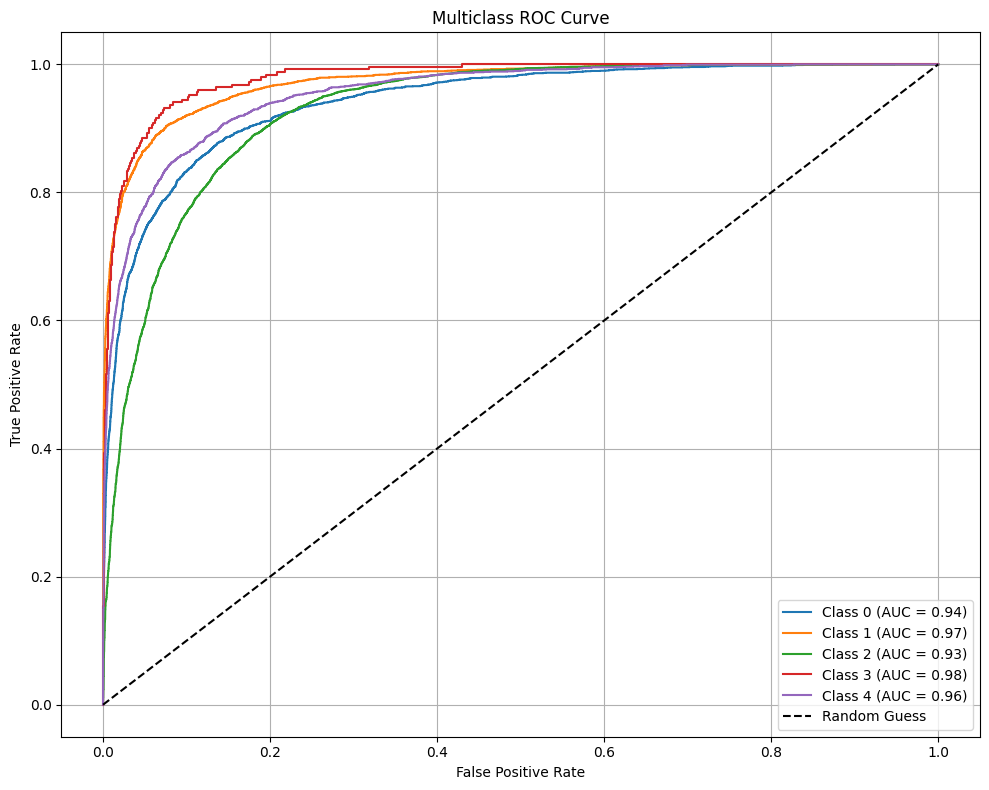

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

model=joblib.load("/content/drive/MyDrive/bug/mlp_3.pkl")
# ✅ Get model predictions
y_score = model.predict(X_test)  # Shape: (num_samples, num_classes)

# ✅ Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Adjust class labels as needed
n_classes = y_test_bin.shape[1]

# ✅ Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# ✅ Plot the baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


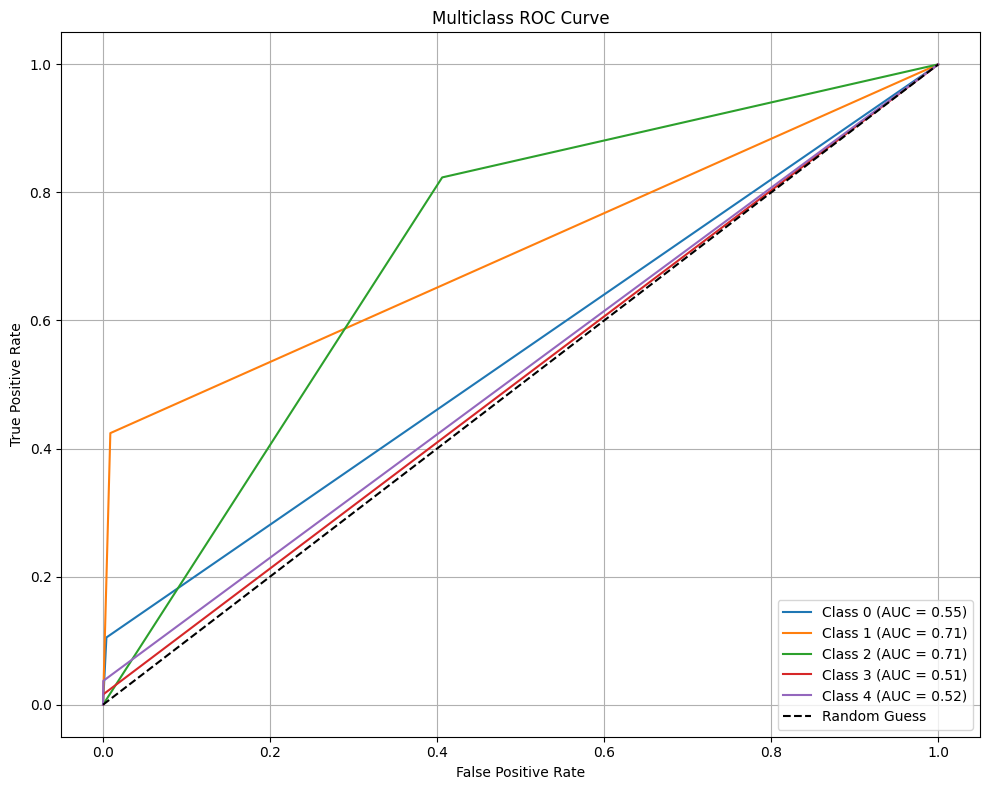

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ✅ Get model predictions
y_score = rf_classifier.predict(X_test)  # Shape: (num_samples, num_classes)

# ✅ Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Adjust class labels as needed
n_classes = y_test_bin.shape[1]

# ✅ Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# ✅ Plot the baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


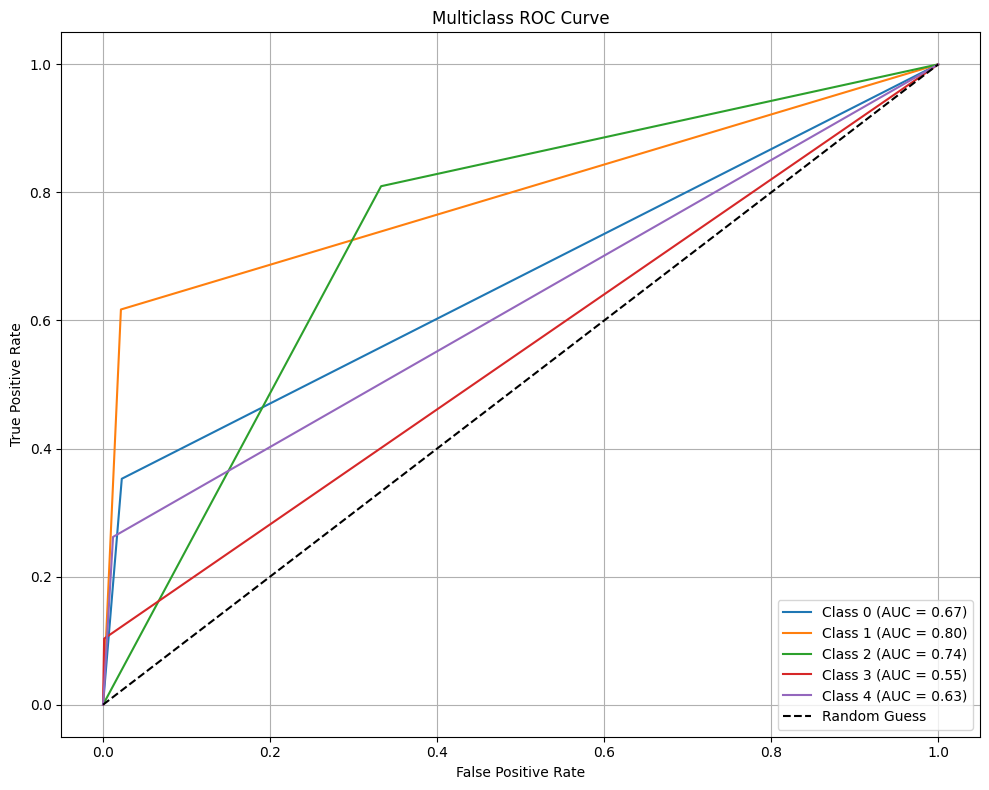

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ✅ Get model predictions
y_score = xgb_classifier.predict(X_test)  # Shape: (num_samples, num_classes)

# ✅ Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Adjust class labels as needed
n_classes = y_test_bin.shape[1]

# ✅ Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# ✅ Plot the baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [ ]:
# Load precomputed embeddings
import numpy as np
bug_embeddings = np.load("/content/drive/My Drive/bug/bug_embeddings1.npy")
bug_labels = np.load("/content/drive/My Drive/bug/bug_labels1.npy")

# Normalize embeddings
scaler = StandardScaler()
bug_embeddings = scaler.fit_transform(bug_embeddings)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert to tensor
bug_embeddings = torch.tensor(bug_embeddings, dtype=torch.float32).to(device)
bug_labels = torch.tensor(bug_labels, dtype=torch.long).to(device)


# Convert embeddings to NumPy for MLP training
X = bug_embeddings.cpu().numpy()
y = bug_labels.cpu().numpy()

In [ ]:
# Split Data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Define MLP Classifier with fixes
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',
                    max_iter=30, alpha=0.05, random_state=42)

# Train Model
mlp.fit(X_train, y_train)

# Evaluate
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ MLP Accuracy (Generalized): {accuracy:.4f}")

✅ MLP Accuracy (Generalized): 0.8938


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
import joblib

# Save the trained MLP model
joblib.dump(mlp, "/content/drive/MyDrive/bug/mlp_5.pkl")  # Adjust path as needed
print("✔️ MLP 2 model saved successfully!")

✔️ MLP 2 model saved successfully!


In [ ]:
# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=300, random_state=42)

# Train the classifier on Siamese embeddings
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")


Random Forest Accuracy: 0.6795


In [ ]:
import joblib

# Save the trained MLP model
joblib.dump(rf_classifier, "/content/drive/MyDrive/bug/rf_classifier_2.pkl")  # Adjust path as needed
print("✔️ MLP 2 model saved successfully!")

✔️ MLP 2 model saved successfully!
